# NYISO Solar Forecasting: Error Analysis

## Purpose

## Research Context

## Questions to Consider

## Imports and Configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

In [2]:
repo_root = Path(r"C:\Users\sumai\Documents\ML_NYISOSolarForecasting")
# repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"

data_root = repo_root / "data"
processed_dir = data_root / "processed"
model_dir = repo_root / "models"

model_ready_in = processed_dir / "04_system_model_ready_data.csv"

## Load Table and Saved Files

In [3]:
df_model = pd.read_csv(model_ready_in, low_memory=False)

df_model.columns = (
    df_model.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df_model["time_stamp"] = pd.to_datetime(df_model["time_stamp"], utc=True, errors="coerce")
df_model["time_local"] = df_model["time_stamp"].dt.tz_convert("America/New_York")

target = "forecast_error_mw"

required_cols = [
    "time_stamp",
    "time_local",
    "zone_name",
    "dataset_split",
    "actual_mw",
    "forecast_mw",
    "forecast_error_mw",
]

missing_required = [c for c in required_cols if c not in df_model.columns]
if missing_required:
    raise ValueError(f"Missing Necessary Columns in Dataset: {missing_required}")

df_model["hour_local"] = df_model["time_local"].dt.hour
df_model["month_local"] = df_model["time_local"].dt.month
df_model["dayofyear_local"] = df_model["time_local"].dt.dayofyear
df_model["is_daylight"] = (df_model["shortwave_radiation"] > 0).astype(int)

feature_cols = [c for c in df_model.columns if c not in required_cols + [
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
]]

if "forecast_mw" not in feature_cols:
    feature_cols = ["forecast_mw"] + feature_cols

In [4]:
test_mask = (
    df_model["dataset_split"].eq("test")
    & df_model[target].notna()
    & df_model["actual_mw"].notna()
    & df_model["forecast_mw"].notna()
)

test_df = df_model.loc[test_mask].copy()
baseline_actual_test = test_df["actual_mw"].copy()
baseline_forecast_test = test_df["forecast_mw"].copy()
daylight_test_mask = test_df["is_daylight"] == 1

validation_results = pd.read_csv(model_dir / "tuned_validation_results.csv")
test_results = pd.read_csv(model_dir / "tuned_test_results.csv")
feature_importance_df = pd.read_csv(model_dir / "tuned_feature_importance.csv")
best_pred_df = pd.read_csv(model_dir / "tuned_best_model_test_predictions.csv")

best_pred_df["time_stamp"] = pd.to_datetime(best_pred_df["time_stamp"], utc=True, errors="coerce")
best_pred_df["time_local"] = pd.to_datetime(best_pred_df["time_local"], errors="coerce")

best_model_name = validation_results.iloc[0]["Model"]
best_test_model_name = test_results.iloc[0]["Model"]

print("Validation-Selected Model:", best_model_name)
print("Best Test Model:", best_test_model_name)

Validation-Selected Model: XGBoost Residual Model (Tuned)
Best Test Model: Random Forest Residual Model (Tuned)


In [5]:
print("\nValidation Results")
print(". . .")
print(validation_results)


Validation Results
. . .
                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0        XGBoost Residual Model (Tuned)  100.675707  196.125174    181.548384     264.847084                  3.286253   
1       LightGBM Residual Model (Tuned)  101.127213  198.320579    182.523356     267.813227                  2.834747   
2       CatBoost Residual Model (Tuned)  102.240913  197.749914    182.373654     267.031912                  1.721047   
3  Random Forest Residual Model (Tuned)  102.199425  199.905960    184.583526     269.979038                  1.762535   
4       Month-Hour Residual Climatology  103.167315  205.765172    186.176641     277.875838                  0.794645   
5                        NYISO Baseline  103.961960  209.115931    187.542605     282.395250                  0.000000   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  


In [6]:
print("\nTest Results")
print(". . .")
print(test_results)


Test Results
. . .
                                  Model         MAE        RMSE  Daylight_MAE  Daylight_RMSE  MAE_Improvement_vs_NYISO  \
0  Random Forest Residual Model (Tuned)   93.644720  189.192249    168.242941     254.902523                 13.257346   
1       CatBoost Residual Model (Tuned)   94.859050  190.162458    169.067847     256.094556                 12.043017   
2        XGBoost Residual Model (Tuned)   95.440422  192.448260    171.172124     259.248514                 11.461645   
3       LightGBM Residual Model (Tuned)   96.014908  192.597245    171.927860     259.361769                 10.887158   
4       Month-Hour Residual Climatology  101.068122  200.765909    181.321095     270.443988                  5.833944   
5                        NYISO Baseline  106.902067  207.701248    190.600140     279.509913                  0.000000   

   RMSE_Improvement_vs_NYISO  Daylight_MAE_Improvement_vs_NYISO  Daylight_RMSE_Improvement_vs_NYISO  Selection_Score  
0     

## Merge Prediction Output to Context Features

In [7]:
analysis_cols = [
    "time_stamp",
    "time_local",
    "hour_local",
    "month_local",
    "dayofyear_local",
    "is_daylight",
    "forecast_error_mw",
    "shortwave_radiation",
    "cloud_cover",
    "temperature_2m",
    "windspeed_10m",
    "surface_pressure",
    "forecast_diff_1",
    "shortwave_diff_1",
    "shortwave_ramp_abs",
    "is_morning_ramp",
    "is_midday",
]

merge_key = ["time_stamp"]
non_key_analysis_cols = [c for c in analysis_cols if c not in merge_key]

best_pred_df["time_stamp"] = pd.to_datetime(best_pred_df["time_stamp"], utc=True, errors="coerce")
test_df["time_stamp"] = pd.to_datetime(test_df["time_stamp"], utc=True, errors="coerce")

analysis_df = (
    best_pred_df.drop(
        columns=[c for c in non_key_analysis_cols if c in best_pred_df.columns],
        errors="ignore",
    )
    .merge(
        test_df[analysis_cols],
        on=merge_key,
        how="left",
        validate="one_to_one",
    )
    .copy()
)

In [8]:
analysis_df["baseline_sq_error_mw"] = analysis_df["baseline_error_mw"] ** 2
analysis_df["model_sq_error_mw"] = analysis_df["model_error_mw"] ** 2

analysis_df["abs_error_reduction_mw"] = (
    analysis_df["baseline_abs_error_mw"] - analysis_df["model_abs_error_mw"]
)
analysis_df["sq_error_reduction_mw"] = (
    analysis_df["baseline_sq_error_mw"] - analysis_df["model_sq_error_mw"]
)

analysis_df["improved_flag"] = (analysis_df["abs_error_reduction_mw"] > 0).astype(int)
analysis_df["worsened_flag"] = (analysis_df["abs_error_reduction_mw"] < 0).astype(int)

analysis_df["baseline_underforecast_flag"] = (analysis_df["baseline_error_mw"] > 0).astype(int)
analysis_df["model_underforecast_flag"] = (analysis_df["model_error_mw"] > 0).astype(int)

analysis_df["abs_error_change_pct"] = np.where(
    analysis_df["baseline_abs_error_mw"] > 0, 
    100 * analysis_df["abs_error_reduction_mw"] / analysis_df["baseline_abs_error_mw"],  
    np.nan,
)

print("Analysis Data Shape:", analysis_df.shape)
print("\nMissing Core Regime Fields:")
print(". . .")
print(analysis_df[["is_daylight", "is_morning_ramp", "is_midday"]].isna().sum())

Analysis Data Shape: (10534, 34)

Missing Core Regime Fields:
. . .
is_daylight        0
is_morning_ramp    0
is_midday          0
dtype: int64


## Summary Helper Function

In [10]:
def summarize_error_block(df):
    return pd.Series({
        "n_obs": len(df),
        "baseline_mae": df["baseline_abs_error_mw"].mean(),
        "model_mae": df["model_abs_error_mw"].mean(),
        "baseline_rmse": np.sqrt(df["baseline_sq_error_mw"].mean()),
        "model_rmse": np.sqrt(df["model_sq_error_mw"].mean()),
        "baseline_bias": df["baseline_error_mw"].mean(),
        "model_bias": df["model_error_mw"].mean(),
        "improved_share": df["improved_flag"].mean(),
        "worsened_share": df["worsened_flag"].mean(),
    })

## Error Summary

In [12]:
residual_summary = pd.DataFrame({
    "metric": [
        "baseline_error_mean",
        "baseline_error_std",
        "model_error_mean",
        "model_error_std",
        "baseline_abs_error_mean",
        "model_abs_error_mean",
        "baseline_rmse",
        "model_rmse",
        "share_rows_improved",
        "share_rows_worsened", 
        "baseline_underforecast_share",
        "model_underforecast_share",
    ],
    "value": [
        analysis_df["baseline_error_mw"].mean(),
        analysis_df["baseline_error_mw"].std(),
        analysis_df["model_error_mw"].mean(),
        analysis_df["model_error_mw"].std(),
        analysis_df["baseline_abs_error_mw"].mean(),
        analysis_df["model_abs_error_mw"].mean(),
        np.sqrt(analysis_df["baseline_sq_error_mw"].mean()),
        np.sqrt(analysis_df["model_sq_error_mw"].mean()),
        analysis_df["improved_flag"].mean(),
        analysis_df["worsened_flag"].mean(), 
        analysis_df["baseline_underforecast_flag"].mean(),
        analysis_df["model_underforecast_flag"].mean(),
    ],
})

residual_summary

,metric,value
0,baseline_error_mean,-14.917052
1,baseline_error_std,207.174720
2,model_error_mean,7.043401
3,model_error_std,192.328455
4,baseline_abs_error_mean,106.902067
5,model_abs_error_mean,95.440422
6,baseline_rmse,207.701248
7,model_rmse,192.448260
8,share_rows_improved,0.350294
9,share_rows_worsened,0.311468


In [13]:
overall_summary = summarize_error_block(analysis_df).to_frame().T
overall_summary["mae_reduction_mw"] = overall_summary["baseline_mae"] - overall_summary["model_mae"]
overall_summary["rmse_reduction_mw"] = overall_summary["baseline_rmse"] - overall_summary["model_rmse"]
overall_summary["mae_reduction_pct"] = 100 * overall_summary["mae_reduction_mw"] / overall_summary["baseline_mae"]
overall_summary["rmse_reduction_pct"] = 100 * overall_summary["rmse_reduction_mw"] / overall_summary["baseline_rmse"]

overall_summary

,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw,mae_reduction_pct,rmse_reduction_pct
0,10534.0,106.902067,95.440422,207.701248,192.44826,-14.917052,7.043401,0.350294,0.311468,11.461645,15.252988,10.72163,7.343715


## Diagnostics by Regime

In [14]:
regime_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_daylight"] == 1, "Daylight", "Non-Daylight"))
    .groupby("regime")
    .apply(summarize_error_block)
    .reset_index()
)

regime_summary["mae_reduction_mw"] = regime_summary["baseline_mae"] - regime_summary["model_mae"]
regime_summary["rmse_reduction_mw"] = regime_summary["baseline_rmse"] - regime_summary["model_rmse"]
regime_summary["mae_reduction_pct"] = 100 * regime_summary["mae_reduction_mw"] / regime_summary["baseline_mae"]
regime_summary["rmse_reduction_pct"] = 100 * regime_summary["rmse_reduction_mw"] / regime_summary["baseline_rmse"]

regime_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw,mae_reduction_pct,rmse_reduction_pct
0,Daylight,5793.0,190.600140,171.172124,279.509913,259.248514,-24.745018,13.374248,0.556534,0.396686,19.428015,20.261399,10.193075,7.248902
1,Non-Daylight,4741.0,4.631884,2.904301,19.764666,12.944514,-2.908319,-0.692224,0.098291,0.207340,1.727583,6.820152,37.297630,34.506790


In [15]:
ramp_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_morning_ramp"] == 1, "Morning Ramp", "Non-Morning Ramp"))
    .groupby("regime")
    .apply(summarize_error_block)
    .reset_index()
)

ramp_summary["mae_reduction_mw"] = ramp_summary["baseline_mae"] - ramp_summary["model_mae"]
ramp_summary["rmse_reduction_mw"] = ramp_summary["baseline_rmse"] - ramp_summary["model_rmse"]
ramp_summary["mae_reduction_pct"] = 100 * ramp_summary["mae_reduction_mw"] / ramp_summary["baseline_mae"] 
ramp_summary["rmse_reduction_pct"] = 100 * ramp_summary["rmse_reduction_mw"] / ramp_summary["baseline_rmse"] 

ramp_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw,mae_reduction_pct,rmse_reduction_pct
0,Morning Ramp,1756.0,128.508098,114.495071,193.849989,178.519794,-30.200387,-1.391281,0.619021,0.350228,14.013027,15.330195,10.904392,7.908278
1,Non-Morning Ramp,8778.0,102.579876,91.628624,210.362687,195.115277,-11.859689,8.730721,0.296537,0.303714,10.951252,15.247410,10.675829,7.248153


In [16]:
midday_summary = (
    analysis_df
    .assign(regime=np.where(analysis_df["is_midday"] == 1, "Midday", "Non-Midday"))
    .groupby("regime")
    .apply(summarize_error_block)
    .reset_index()
)

midday_summary["mae_reduction_mw"] = midday_summary["baseline_mae"] - midday_summary["model_mae"]
midday_summary["rmse_reduction_mw"] = midday_summary["baseline_rmse"] - midday_summary["model_rmse"]
midday_summary["mae_reduction_pct"] = 100 * midday_summary["mae_reduction_mw"] / midday_summary["baseline_mae"]  
midday_summary["rmse_reduction_pct"] = 100 * midday_summary["rmse_reduction_mw"] / midday_summary["baseline_rmse"] 

midday_summary

,regime,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw,mae_reduction_pct,rmse_reduction_pct
0,Midday,2195.0,277.229185,260.390913,365.653830,348.220553,11.504483,29.652942,0.553531,0.446469,16.838271,17.433277,6.073773,4.767700
1,Non-Midday,8339.0,62.068391,52.021987,138.930726,121.932513,-21.871756,1.092094,0.296798,0.275932,10.046403,16.998212,16.186022,12.235027


## Diagnostics by Temporal Features

In [17]:
hourly_day = (
    analysis_df.loc[analysis_df["is_daylight"] == 1]
    .groupby("hour_local")
    .apply(summarize_error_block)
    .reset_index()
)

hourly_day["mae_reduction_mw"] = hourly_day["baseline_mae"] - hourly_day["model_mae"]
hourly_day["rmse_reduction_mw"] = hourly_day["baseline_rmse"] - hourly_day["model_rmse"]

hourly_day

,hour_local,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw
0,6,100.0,58.587700,52.895555,73.086543,68.655748,-15.852900,17.150477,0.620000,0.380000,5.692145,4.430795
1,7,275.0,108.017455,91.778774,137.278069,122.661175,-41.590109,1.484393,0.654545,0.345455,16.238680,14.616894
2,8,439.0,162.457722,149.243411,210.557939,196.981721,-37.394624,-0.430840,0.585421,0.414579,13.214312,13.576218
3,9,439.0,224.823599,211.679043,298.025428,276.412931,-24.757677,-2.854571,0.558087,0.441913,13.144556,21.612497
4,10,439.0,262.205581,245.129519,350.488018,324.246884,-1.287403,15.176315,0.558087,0.441913,17.076062,26.241134
5,11,439.0,291.078041,271.396465,378.807233,358.937805,24.720364,31.128381,0.560364,0.439636,19.681576,19.869428
6,12,439.0,298.308656,280.305170,389.227427,374.553012,28.662733,36.011984,0.544419,0.455581,18.003486,14.674416
7,13,439.0,279.431185,265.379766,368.171888,357.950160,14.885672,41.515171,0.555809,0.444191,14.051418,10.221728
8,14,439.0,255.122460,239.743646,339.305640,322.330737,-9.458952,24.432860,0.548975,0.451025,15.378814,16.974903
9,15,439.0,217.429863,197.394531,299.420421,271.774597,-42.539841,14.592387,0.551253,0.448747,20.035332,27.645824


In [18]:
monthly_all = (
    analysis_df
    .groupby("month_local")
    .apply(summarize_error_block)
    .reset_index()
)

monthly_all["mae_reduction_mw"] = monthly_all["baseline_mae"] - monthly_all["model_mae"]
monthly_all["rmse_reduction_mw"] = monthly_all["baseline_rmse"] - monthly_all["model_rmse"] 

monthly_all

,month_local,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw
0,1,744.0,90.022392,95.167722,211.440929,227.695067,22.543495,26.539426,0.215054,0.385753,-5.145329,-16.254137
1,2,672.0,99.201726,87.993045,207.269024,196.017773,63.368363,51.354661,0.278274,0.369048,11.208681,11.251251
2,3,743.0,132.075249,115.444733,273.291661,238.363677,40.806393,16.966534,0.329744,0.414536,16.630516,34.927984
3,4,720.0,108.603139,109.121711,203.792935,206.950722,6.195889,10.192742,0.290278,0.487500,-0.518572,-3.157787
4,5,714.0,128.481835,121.584769,240.350651,228.235019,15.765700,38.293901,0.329132,0.446779,6.897066,12.115633
5,6,724.0,110.084033,102.623485,212.597966,196.928638,-7.001713,19.262109,0.345304,0.390884,7.460548,15.669328
6,7,1488.0,117.917507,110.480216,210.342850,200.785795,-25.770827,6.537746,0.385081,0.387097,7.437291,9.557054
7,8,1488.0,110.636028,93.110333,201.017856,175.942600,-45.034227,-1.183844,0.453629,0.212366,17.525695,25.075256
8,9,1152.0,109.597682,85.701569,192.489326,160.735364,-45.838932,1.474658,0.413194,0.180556,23.896113,31.753962
9,10,696.0,97.709497,73.010728,171.340070,141.073831,-63.242486,-36.768465,0.412356,0.135057,24.698769,30.266240


## Diagonistics by Weather Features

In [20]:
weather_vars = [
    "forecast_mw",
    "shortwave_radiation",
    "cloud_cover",
    "temperature_2m",
    "shortwave_ramp_abs",
]

for col in weather_vars:
    analysis_df[f"{col}_bin"] = pd.qcut(analysis_df[col], q=5, duplicates="drop")

In [21]:
weather_summary_frames = []

for col in weather_vars:
    tmp = (
        analysis_df
        .groupby(f"{col}_bin", observed=False)
        .apply(summarize_error_block)
        .reset_index()
    )
    tmp["variable"] = col
    tmp["bin"] = tmp[f"{col}_bin"].astype(str)
    tmp["mae_reduction_mw"] = tmp["baseline_mae"] - tmp["model_mae"]
    tmp["rmse_reduction_mw"] = tmp["baseline_rmse"] - tmp["model_rmse"]

    weather_summary_frames.append(
        tmp[[
            "variable",
            "bin",
            "n_obs",
            
            "baseline_mae",
            "model_mae",
            
            "baseline_rmse",
            "model_rmse",
            
            "baseline_bias",
            "model_bias",
            
            "improved_share",
            "worsened_share",
            
            "mae_reduction_mw",
            "rmse_reduction_mw", 
        ]]
    )

weather_summary_df = pd.concat(weather_summary_frames, ignore_index=True)

weather_summary_df

,variable,bin,n_obs,baseline_mae,model_mae,baseline_rmse,model_rmse,baseline_bias,model_bias,improved_share,worsened_share,mae_reduction_mw,rmse_reduction_mw
0,forecast_mw,"(-0.001, 554.738]",6320.0,16.808767,11.832562,48.386002,37.806775,-7.699922,1.437822,0.199842,0.236392,4.976205,10.579227
1,forecast_mw,"(554.738, 1901.806]",2107.0,238.455197,206.006960,318.279065,284.848176,-60.311115,1.470713,0.617466,0.382534,32.448237,33.430888
2,forecast_mw,"(1901.806, 5192.28]",2107.0,245.586075,235.657784,327.649966,315.813590,8.829046,29.430162,0.534409,0.465591,9.928291,11.836376
3,shortwave_radiation,"(-0.001, 97.0]",6332.0,26.126104,20.182635,81.333006,67.000383,-13.755573,-3.007262,0.205938,0.231364,5.943469,14.332623
4,shortwave_radiation,"(97.0, 381.0]",2096.0,207.485964,182.914233,285.607285,264.051428,-59.238779,10.292028,0.585878,0.414122,24.571731,21.555857
5,shortwave_radiation,"(381.0, 965.0]",2106.0,249.660636,234.655618,338.685161,319.942064,25.702061,34.028999,0.549858,0.450142,15.005018,18.743098
6,cloud_cover,"(-0.001, 7.0]",2148.0,86.070819,77.370996,182.329761,173.236218,-14.724479,-2.973686,0.314246,0.313780,8.699823,9.093543
7,cloud_cover,"(7.0, 64.0]",2086.0,119.094166,108.071634,211.552632,197.799024,-0.362114,20.798001,0.408437,0.333653,11.022532,13.753607
8,cloud_cover,"(64.0, 100.0]",6300.0,109.967590,97.418901,214.427405,196.825580,-19.802013,5.904449,0.343333,0.303333,12.548689,17.601825
9,temperature_2m,"(-23.801000000000002, -0.8]",2125.0,91.895967,88.534269,207.532854,208.351940,19.136080,18.665635,0.244706,0.367059,3.361698,-0.819086


## Distribution and Case-Based Diagnostics

In [22]:
distribution_summary = pd.DataFrame({
    "metric": [
        "baseline_p50_abs_error",
        "model_p50_abs_error",
        "baseline_p90_abs_error",
        "model_p90_abs_error",
        "baseline_p95_abs_error",
        "model_p95_abs_error",
        "baseline_p99_abs_error",
        "model_p99_abs_error",
    ],
    "value": [
        analysis_df["baseline_abs_error_mw"].quantile(0.50),
        analysis_df["model_abs_error_mw"].quantile(0.50),
        analysis_df["baseline_abs_error_mw"].quantile(0.90),
        analysis_df["model_abs_error_mw"].quantile(0.90),
        analysis_df["baseline_abs_error_mw"].quantile(0.95),
        analysis_df["model_abs_error_mw"].quantile(0.95),
        analysis_df["baseline_abs_error_mw"].quantile(0.99),
        analysis_df["model_abs_error_mw"].quantile(0.99),
    ],
})

distribution_summary

,metric,value
0,baseline_p50_abs_error,13.510000
1,model_p50_abs_error,8.660193
2,baseline_p90_abs_error,344.973000
3,model_p90_abs_error,308.302916
4,baseline_p95_abs_error,470.260500
5,model_p95_abs_error,442.187820
6,baseline_p99_abs_error,801.731500
7,model_p99_abs_error,773.549749


In [23]:
worst_baseline_cases = analysis_df.nlargest(20, "baseline_abs_error_mw")[
    [
        "time_local",
        "actual_mw",
        "forecast_mw",
        "corrected_forecast_mw",
        "baseline_abs_error_mw",
        "model_abs_error_mw",
        "abs_error_reduction_mw",
        "shortwave_radiation",
        "cloud_cover",
        "temperature_2m",
        "is_daylight",
        "is_morning_ramp",
        "is_midday",
    ]
].copy()

print("Worst Baseline Cases")
print(". . .")
display(worst_baseline_cases)

Worst Baseline Cases
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error_mw,model_abs_error_mw,abs_error_reduction_mw,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
6018,2025-03-13 14:00:00-04:00,3548.73,1824.38,1927.201014,1724.35,1621.528986,102.821014,713.0,99,9.5,1,0,1
6017,2025-03-13 13:00:00-04:00,3657.99,1938.83,2095.429854,1719.16,1562.560146,156.599854,701.0,92,8.6,1,0,1
6016,2025-03-13 12:00:00-04:00,3679.71,2001.04,2130.060157,1678.67,1549.649843,129.020157,635.0,96,7.2,1,0,1
6015,2025-03-13 11:00:00-04:00,3566.88,1996.87,2169.629430,1570.01,1397.250570,172.759430,500.0,58,5.3,1,0,1
6019,2025-03-13 15:00:00-04:00,3154.19,1611.26,1716.363287,1542.93,1437.826713,105.103287,646.0,99,9.9,1,0,0
6014,2025-03-13 10:00:00-04:00,3133.48,1815.68,2003.687553,1317.80,1129.792447,188.007553,348.0,74,3.3,1,0,1
4144,2024-12-22 11:00:00-05:00,774.06,2082.91,2218.349438,1308.85,1444.289438,-135.439438,367.0,1,-17.9,1,0,1
7480,2025-05-13 12:00:00-04:00,2539.80,1244.29,1567.588401,1295.51,972.211599,323.298401,546.0,100,20.9,1,0,1
4145,2024-12-22 12:00:00-05:00,787.13,2022.55,2155.243115,1235.42,1368.113115,-132.693115,425.0,1,-16.9,1,0,1
4143,2024-12-22 10:00:00-05:00,676.63,1905.37,1929.494077,1228.74,1252.864077,-24.124077,257.0,2,-18.8,1,0,1


In [24]:

largest_improvements = analysis_df.nlargest(20, "abs_error_reduction_mw")[
    [
        "time_local",
        "actual_mw",
        "forecast_mw",
        "corrected_forecast_mw",
        "baseline_abs_error_mw",
        "model_abs_error_mw",
        "abs_error_reduction_mw",
        "shortwave_radiation",
        "cloud_cover",
        "temperature_2m",
        "is_daylight",
        "is_morning_ramp",
        "is_midday",
    ]
].copy()

print("\nLargest Improvements")
print(". . .")
display(largest_improvements)


Largest Improvements
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error_mw,model_abs_error_mw,abs_error_reduction_mw,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
7910,2025-06-01 16:00:00-04:00,1527.10,1926.32,1510.570397,399.22,16.529603,382.690397,379.0,100,10.6,1,0,0
5873,2025-03-07 12:00:00-05:00,3212.06,2358.33,2734.092085,853.73,477.967915,375.762085,698.0,21,-2.9,1,0,1
2107,2024-09-26 15:00:00-04:00,985.12,1360.79,997.174918,375.67,12.054918,363.615082,292.0,100,17.3,1,0,0
5656,2025-02-26 11:00:00-05:00,3274.19,2378.21,2741.066659,895.98,533.123341,362.856659,594.0,83,0.5,1,0,1
2106,2024-09-26 14:00:00-04:00,1098.99,1548.67,1190.947496,449.68,91.957496,357.722504,89.0,100,16.5,1,0,1
5610,2025-02-24 13:00:00-05:00,2540.40,1864.78,2220.303834,675.62,320.096166,355.523834,585.0,97,3.4,1,0,1
5659,2025-02-26 14:00:00-05:00,2094.01,1728.91,2080.881344,365.10,13.128656,351.971344,556.0,92,0.7,1,0,1
7909,2025-06-01 15:00:00-04:00,1945.42,2334.79,1905.650779,389.37,39.769221,349.600779,573.0,98,11.1,1,0,0
5658,2025-02-26 13:00:00-05:00,2702.80,2153.29,2499.842643,549.51,202.957357,346.552643,600.0,99,0.7,1,0,1
1650,2024-09-07 14:00:00-04:00,1377.38,1789.51,1448.796469,412.13,71.416469,340.713531,67.0,100,12.9,1,0,1


In [25]:
largest_deteriorations = analysis_df.nsmallest(20, "abs_error_reduction_mw")[
    [
        "time_local",
        "actual_mw",
        "forecast_mw",
        "corrected_forecast_mw",
        "baseline_abs_error_mw",
        "model_abs_error_mw",
        "abs_error_reduction_mw",
        "shortwave_radiation",
        "cloud_cover",
        "temperature_2m",
        "is_daylight",
        "is_morning_ramp",
        "is_midday",
    ]
].copy()

print("\nLargest Deteriorations")
print(". . .")
display(largest_deteriorations)


Largest Deteriorations
. . .


,time_local,actual_mw,forecast_mw,corrected_forecast_mw,baseline_abs_error_mw,model_abs_error_mw,abs_error_reduction_mw,shortwave_radiation,cloud_cover,temperature_2m,is_daylight,is_morning_ramp,is_midday
6258,2025-03-23 14:00:00-04:00,3764.45,3785.45,4283.173999,21.00,518.723999,-497.723999,817.0,10,-0.9,1,0,1
6257,2025-03-23 13:00:00-04:00,4043.83,4004.08,4538.824385,39.75,494.994385,-455.244385,809.0,0,-2.0,1,0,1
8029,2025-06-06 15:00:00-04:00,1974.28,1909.06,1506.980380,65.22,467.299620,-402.079620,158.0,100,18.6,1,0,0
6256,2025-03-23 12:00:00-04:00,4118.51,4039.92,4539.981157,78.59,421.471157,-342.881157,738.0,0,-3.4,1,0,1
6616,2025-04-07 12:00:00-04:00,1841.30,1940.86,2274.343459,99.56,433.043459,-333.483459,667.0,100,4.3,1,0,1
3929,2024-12-13 12:00:00-05:00,2084.19,1932.11,1616.794052,152.08,467.395948,-315.315948,219.0,100,-6.9,1,0,1
7651,2025-05-20 15:00:00-04:00,2891.01,2624.61,2323.505630,266.40,567.504370,-301.104370,477.0,100,10.4,1,0,0
6328,2025-03-26 12:00:00-04:00,2401.95,2427.65,2725.559912,25.70,323.609912,-297.909912,540.0,99,1.7,1,0,1
5201,2025-02-07 12:00:00-05:00,2654.97,1989.06,1693.860934,665.91,961.109066,-295.199066,241.0,98,-7.6,1,0,1
4650,2025-01-15 13:00:00-05:00,1459.24,1390.85,1097.871179,68.39,361.368821,-292.978821,221.0,100,-8.6,1,0,1


## Rolling Error Series for Stability 

In [26]:
analysis_df = analysis_df.sort_values("time_stamp").reset_index(drop=True)
analysis_df["baseline_mae_168h"] = analysis_df["baseline_abs_error_mw"].rolling(24 * 7, min_periods=1).mean()
analysis_df["model_mae_168h"] = analysis_df["model_abs_error_mw"].rolling(24 * 7, min_periods=1).mean()

recent_plot = analysis_df.tail(min(24 * 30, len(analysis_df))).copy()

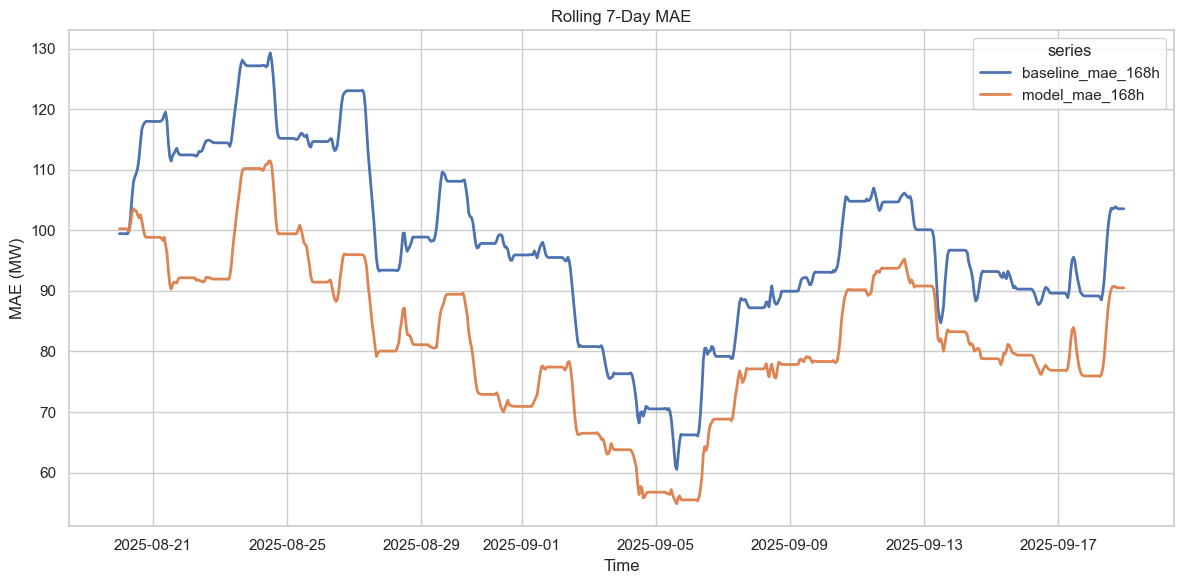

In [31]:
rolling_plot = recent_plot.melt(
    id_vars="time_local",
    value_vars=["baseline_mae_168h", "model_mae_168h"],
    var_name="series",
    value_name="mae_mw",
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=rolling_plot, x="time_local", y="mae_mw", hue="series", linewidth=2)
plt.title("Rolling 7-Day MAE")
plt.xlabel("Time")
plt.ylabel("MAE (MW)")
plt.tight_layout()
plt.show()

## Visualization

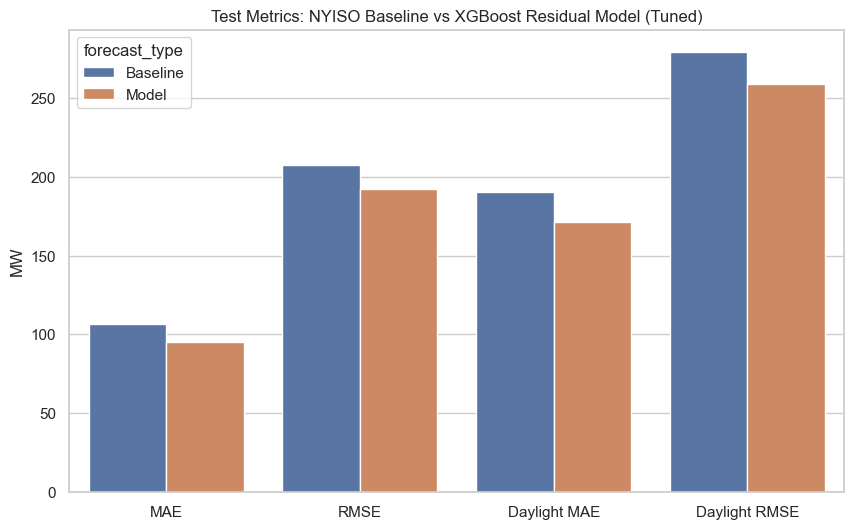

In [32]:
metric_plot_df = pd.DataFrame({
    "metric": ["MAE", "RMSE", "Daylight MAE", "Daylight RMSE"],
    "Baseline": [
        test_results.loc[test_results["Model"] == "NYISO Baseline", "MAE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "RMSE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "Daylight_MAE"].iloc[0],
        test_results.loc[test_results["Model"] == "NYISO Baseline", "Daylight_RMSE"].iloc[0],
    ],
    "Model": [
        test_results.loc[test_results["Model"] == best_model_name, "MAE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model_name, "RMSE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model_name, "Daylight_MAE"].iloc[0],
        test_results.loc[test_results["Model"] == best_model_name, "Daylight_RMSE"].iloc[0],
    ],
}).melt(id_vars="metric", var_name="forecast_type", value_name="value")


plt.figure(figsize=(10, 6))
sns.barplot(data=metric_plot_df, x="metric", y="value", hue="forecast_type")
plt.title(f"Test Metrics: NYISO Baseline vs {best_model_name}")
plt.xlabel("")
plt.ylabel("MW")
plt.show()

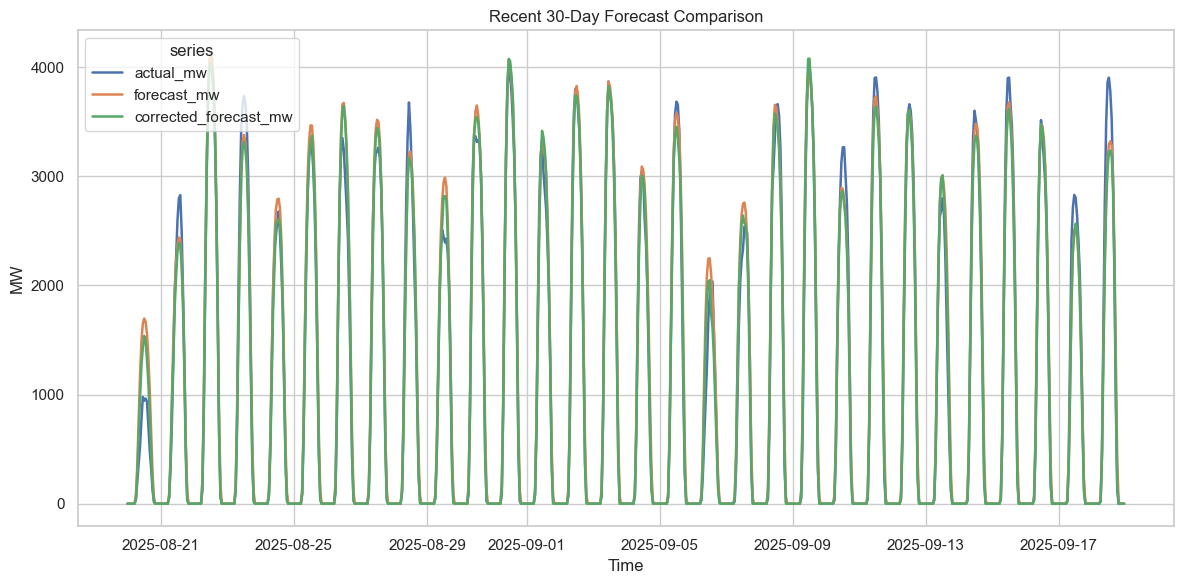

In [33]:
recent_forecast_plot = recent_plot.melt(
    id_vars="time_local",
    value_vars=["actual_mw", "forecast_mw", "corrected_forecast_mw"],
    var_name="series",
    value_name="mw",
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=recent_forecast_plot, x="time_local", y="mw", hue="series", linewidth=1.8)
plt.title("Recent 30-Day Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("MW")
plt.tight_layout()
plt.show()

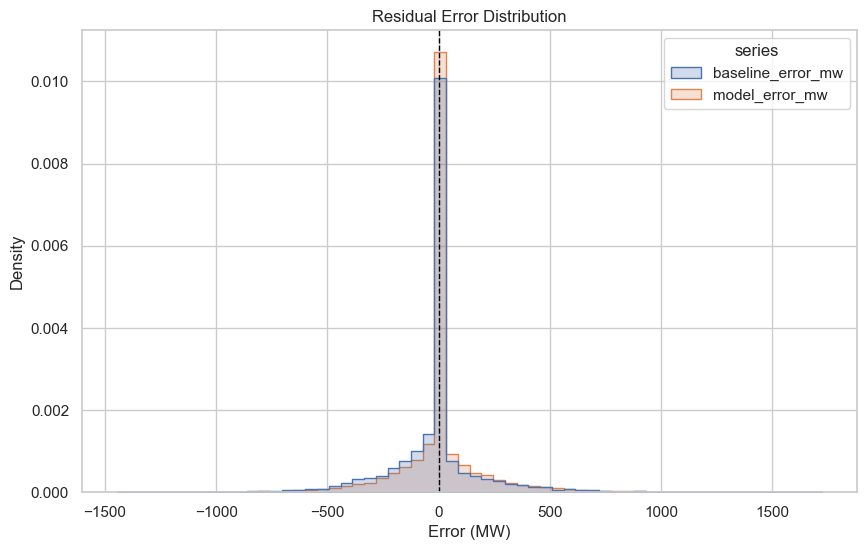

In [35]:
dist_plot = analysis_df.melt(
    value_vars=["baseline_error_mw", "model_error_mw"],
    var_name="series",
    value_name="error_mw",
)

plt.figure(figsize=(10, 6))
sns.histplot(data=dist_plot, x="error_mw", hue="series", bins=60, stat="density", common_norm=False, element="step")
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Residual Error Distribution")
plt.xlabel("Error (MW)")
plt.ylabel("Density")
plt.show()

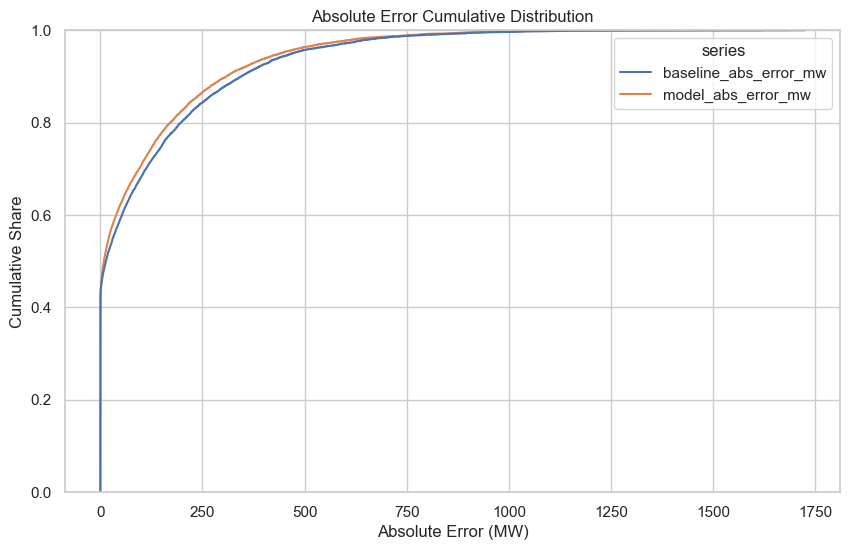

In [40]:
tail_plot = analysis_df.melt(
    value_vars=["baseline_abs_error_mw", "model_abs_error_mw"],
    var_name="series",
    value_name="abs_error_mw",
)

plt.figure(figsize=(10, 6))
sns.ecdfplot(data=tail_plot, x="abs_error_mw", hue="series")
plt.title("Absolute Error Cumulative Distribution")
plt.xlabel("Absolute Error (MW)")
plt.ylabel("Cumulative Share")
plt.show()

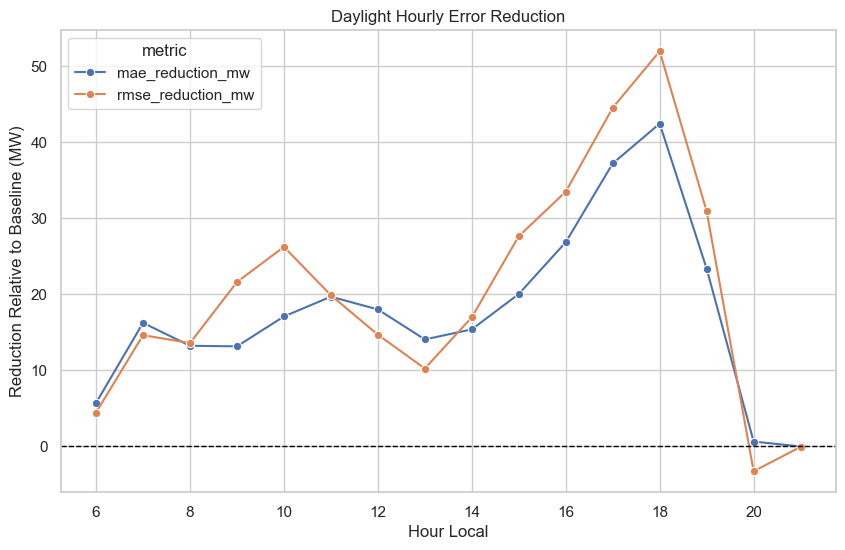

In [43]:
improvement_hour_plot = hourly_day[["hour_local", "mae_reduction_mw", "rmse_reduction_mw"]].melt(  
    id_vars="hour_local",  
    var_name="metric",    
    value_name="reduction_mw",  
) 

plt.figure(figsize=(10, 6)) 
sns.lineplot(data=improvement_hour_plot, x="hour_local", y="reduction_mw", hue="metric", marker="o") 
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.title("Daylight Hourly Error Reduction")  
plt.xlabel("Hour Local")  
plt.ylabel("Reduction Relative to Baseline (MW)") 
plt.show()  

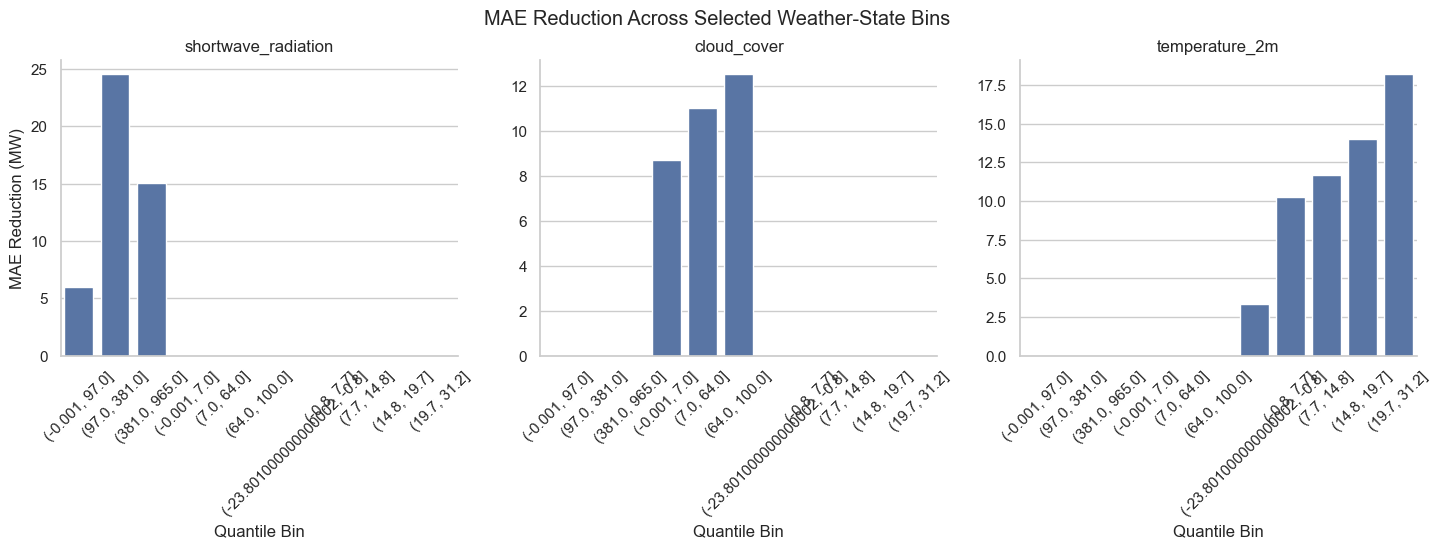

In [44]:
weather_plot_df = weather_summary_df.copy() 
weather_plot_df = weather_plot_df.loc[weather_plot_df["variable"].isin(["shortwave_radiation", "cloud_cover", "temperature_2m"])]

g = sns.catplot( 
    data=weather_plot_df, 
    kind="bar",  
    x="bin",  
    y="mae_reduction_mw", 
    col="variable",  
    sharey=False, 
    height=4, 
    aspect=1.2,  
) 
g.set_axis_labels("Quantile Bin", "MAE Reduction (MW)")
g.set_titles("{col_name}") 
for ax in g.axes.flat:  
    ax.tick_params(axis="x", rotation=45) 
g.figure.suptitle("MAE Reduction Across Selected Weather-State Bins", y=1.03) 
plt.show() 

In [46]:
residual_summary.to_csv(model_dir / "error_analysis_residual_summary.csv", index=False)
overall_summary.to_csv(model_dir / "error_analysis_overall_summary.csv", index=False)
regime_summary.to_csv(model_dir / "error_analysis_regime_summary.csv", index=False)
ramp_summary.to_csv(model_dir / "error_analysis_ramp_summary.csv", index=False)
midday_summary.to_csv(model_dir / "error_analysis_midday_summary.csv", index=False)
hourly_day.to_csv(model_dir / "error_analysis_hourly_daylight_summary.csv", index=False)
monthly_all.to_csv(model_dir / "error_analysis_monthly_summary.csv", index=False)
weather_summary_df.to_csv(model_dir / "error_analysis_weather_summary.csv", index=False)
distribution_summary.to_csv(model_dir / "error_analysis_distribution_summary.csv", index=False)
worst_baseline_cases.to_csv(model_dir / "error_analysis_worst_baseline_cases.csv", index=False)
largest_improvements.to_csv(model_dir / "error_analysis_largest_improvements.csv", index=False)
largest_deteriorations.to_csv(model_dir / "error_analysis_largest_deteriorations.csv", index=False)

analysis_df.to_csv(model_dir / "error_analysis_best_pred_df.csv", index=False)

## Conclusion and Next Steps